TF version: 2.19.0
Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 77s 551ms/step - accuracy: 0.9389 - loss: 0.1415 - val_accuracy: 0.9778 - val_loss: 0.0574
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 47s 398ms/step - accuracy: 0.9768 - loss: 0.0610 - val_accuracy: 0.9862 - val_loss: 0.0427
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 47s 398ms/step - accuracy: 0.9866 - loss: 0.0362 - val_accuracy: 0.9873 - val_loss: 0.0601
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 48s 405ms/step - accuracy: 0.9924 - loss: 0.0229 - val_accuracy: 0.9862 - val_loss: 0.0432


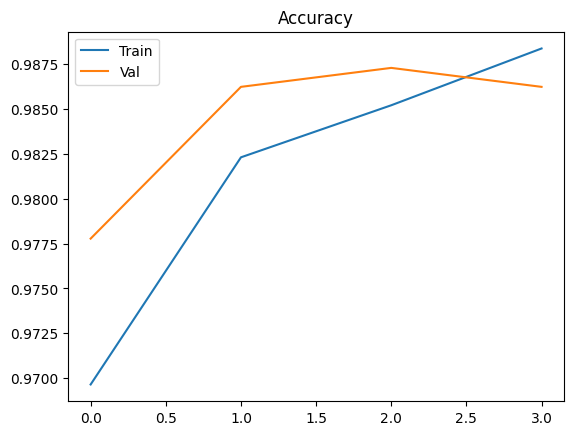

✅ submission.csv created!


In [5]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2   # 🔁 can change to ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

print("TF version:", tf.__version__)

# =========================================================
# 2. PATHS (CHANGE THIS ⚠️)
# =========================================================

TRAIN_DIR = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train"   # folder with class subfolders
TEST_DIR  = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final"    # flat folder (no subfolders)

IMG_SIZE = (160,160)   # 🔥 faster than 224, almost same accuracy
BATCH_SIZE = 32

# =========================================================
# 3. DATA GENERATOR (OVERFITTING CONTROL 🔥)
# =========================================================

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',   # 🔁 change to 'categorical' if >2 classes
    subset='training'
)

val_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# =========================================================
# 4. MODEL (TRANSFER LEARNING 🔥 BEST)
# =========================================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False   # 🔥 prevents overfitting

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),   # 🔥 overfitting control
    layers.Dense(1, activation='sigmoid')   # 🔁 softmax if multi-class
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================================
# 5. TRAIN (FAST + SAFE)
# =========================================================

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop]
)

# =========================================================
# 6. (OPTIONAL) FINE-TUNING 🔥 (SECOND SUBMISSION)
# =========================================================

# 🔁 Uncomment only if time mile

"""
for layer in base_model.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_gen, validation_data=val_gen, epochs=2)
"""

# =========================================================
# 7. PLOT (FOR UNDERSTANDING)
# =========================================================

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='Train')
plt.plot(val_acc, label='Val')
plt.legend()
plt.title("Accuracy")
plt.show()

# =========================================================
# 8. TEST PREDICTION (UNIVERSAL FIXED 🔥)
# =========================================================

test_images = [img for img in os.listdir(TEST_DIR)
               if img.endswith(('.jpg','.png','.jpeg'))]

predictions = []

for img_name in test_images:
    img_path = os.path.join(TEST_DIR, img_name)

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]
    label = 1 if pred > 0.5 else 0   # 🔁 adjust if needed
    predictions.append(label)

# =========================================================
# 9. SUBMISSION FILE
# =========================================================

submission = pd.DataFrame({
    "id": test_images,   # ⚠️ check column name in competition
    "label": predictions
})

submission.to_csv("submission.csv", index=False)

print("✅ submission.csv created!")